# Reinforcement learning

## Introduction
Reinforcement learning is a problem formulation for sequential decision making under uncertainty. The agent's role in this interaction is to choose an action on each time step. The choice of action has an immediate impact on both the immediate reward, and the next state. To make choices, agents follow policies. It's important that policies depend only on the current state, not on other things like time or previous states. The state defines all the information used to select the current action. The objective of a policy being to maximize expected returns/rewards.

A policy could consist in choosing randomly between Left and Right.  
We might also want to define a policy that chooses alternating between Left and Right actions. However, that would not be a valid policy because this is conditional on the last action. That means the action depends on something other than the state.  
In MDPs, we assume that the state includes all the information required for decision-making. If alternating between Left and Right would yield a higher return, then the last action should be included in the state to satisfy the MDP condition.

Roughly speaking, a state value function ($v$) is the future award an agent can expect to receive starting from a particular state. More precisely, the state value function is the expected return from a given state. The agent's behavior will also determine how much total reward it can expect. So a value function is defined with respect to a given policy.

We can also define an action value function ($q$). An action value describes what happens when the agent first selects a particular action. More formally, the action value of a state is the expected return if the agent selects action A and then follows policy Pi.

**We must specify the policy before we can figure out what the value function is.**


### 2 components
RL is defined by two components: a value function and a decision policy function. RL is implemented in Markov Decision Processes.


### Markov Decision Process (MDP) 
A situation is a MDP if it is fully defined by:
* We can define the environment by a set of possible states: $S={s_{0},s_{1},...,s_{n}}$
* We can define an initial state $s_{0}$
* A transition model: how the state changes over time $p(s'|s,t)$

Therefore a MDP is a 4-tuple $(S,A,P_{a},R_{a})$:
* $S$ is a set of states called the state space,
* $𝐴$ is a set of actions called the action space (alternatively, $𝐴_{s}$ is the set of actions available from state $𝑠$ 
* $𝑃_{a}(𝑠,𝑠′) = Pr(𝑠_{𝑡+1} = 𝑠′ ∣ 𝑠_{𝑡} = 𝑠, 𝑎_{t}𝑡 = 𝑎)$ is the probability that action $𝑎$ in state $𝑠$ at time $𝑡$ will lead to state $𝑠'$ at time $𝑡 + 1$ {\displaystyle t+1},
* $𝑅_{a}(𝑠,𝑠′)$ is the immediate reward (or expected immediate reward) received after transitioning from state $𝑠$ to state $𝑠′$, due to action $𝑎$


### Markov Chains
Markov chains are systems that experiences transitions from one state to another according to probabilistic rules.  
The defining characteristic of a Markov chain is that no matter how the process arrived at its present state, the possible future states are fixed.  
In other words, the probability of transitioning to any particular state is dependent solely on the current state and time elapsed. 


### Markov Property
The Markov property:
- Markov chains and Markov decision proceses must both adhere to the Markov Property.
- A stochastic process has the Markov property if the conditional probability distribution of future states of the process (conditional on both past and present values) depends only upon the present state; that is, given the present, the future does not depend on the past.

"The future should be unconditionnaly defined by the present".  
Therefore, we don't need to know **all** the previous states in order to predict what will happen next; knowing the current state is sufficient.  
"Knowing $s_{t-1}$ is just as useful as knowing any collection of previous states."

In other words, a game of chess has a Markov Property. If one sees the current state of a chess position, one has **enough information to play optimally**. Therefore, knowing the history of plays is not useful.


### Observation of MDP
* Fully observable (FOMDP): If the agent can see the full state of the world (e.g., chess). Then it knows the transition probabilities and can apply a decision policy (e.g., as in Game Theory?)
* Partially observable (POMDP): If the agent can't see the full state of the world (e.g., poker). Because the agent cannot directly observe the underlying state, it needs a sensor model (the probability distribution of different observations given the underlying state). Then POMDP policy is a mapping from the history of observations. The agent needs to infer the transition probabilities to apply a decision policy.


### Finite MDP and infinite MDP
In finite MDP, the sets of states, actions and rewards are finite.


### Model-based MDP and Model-free MDP
- **Model-based**
When an agent explicitly uses a transition model (or estimate thereof) in its policy, we call this **Model-based RL**.  
Methods: Iterative Policy methods are used to identify the values of Q (such as Dynamic Programming).

- **Model-free**
But sometimes the transition model is unknown by the agent. Then the agent could try to learn the dynamics model from the experience it gets.  
Methods: Monte-Carlo and Temporal Difference (TD, TD(0), TD(λ)).  
TD is a bootstrapping method: estimating one value from the estimate of another value.


### Goal of agents
Agents are maximizing total future rewards.  
Their return at time step t is simply the sum of all rewards obtained **after** time step t:
$$G_{t} = R_{t+1} + R_{t+2} + R_{t+3} + ...$$  

G is usually a random variable because rewards are usually stochastic. This is why we maximize the expected return.


### Policy for action selection
A policy $π$, according to Reinforcement Learning: An Introduction by Sutton and Barto is a function $π:S→A$.
* Deterministic policy ($π(s)=a$): action chosen from a particular state is deterministic and priorly assigned
* Stochastic policy ($π(a|s)$): action chosen from a particular state is stochastic and determined by probabilities fo each state
Policies are usually stochastic. Multiple actions mauy be selected from one state, with non-zero probabilitiy.

For instance:
- Greedy policy: choose the action with the greater value
- Epsilon-Greedy policy: be greedy but with an epsilon parameter that allows to randomly select between actions
- Boltzmann policy: softmax for probabilistic action selection
- Upper-Confidence-Bound (UCB): UCB follows what is called optimism in the face of uncertainty. This means that if we don’t have enough confidence $U(a)$ on a value of an action, assume it is optimum and select it. We no longer select actions that maximize $Q(a)$, we rather select actions to maximize $Q(a) + U(a)$. Focusing on the highest upper confidence bound allows to maximize the value and the uncertainty, compared to lower bound.

Policy evaluation is the task of determining the value function for a specific policy.  
Control/Policy improvement is the task of finding a policy to obtain as much reward as possible. In other words, finding a policy which maximizes the value function.  
Control is the ultimate goal of reinforcement learning. But the task of policy evaluation is usually a necessary first step.


### Value functions:
* $Vπ(s)$ is the **"state" value function** of an MDP (Markov Decision Process). It's the expected return starting from state $s$ following policy $π$. A value function is defined with respect to a given policy:
$$V^π(s)=E_{π}[{G_{t}|s_{t}=s}]$$
* $Q^π(s,a)$ is the **"state action" value function**, also known as the quality function or the **action-value function**. It is the expected return starting from state $s$, taking action $a$, then following policy $π$. It's focusing on the particular action at the particular state:
$$Q^π(s,a)=E_{π}[{G_{t}|s_{t}=s,a_{t}=a}]$$
* $G_{t}$ is the total DISCOUNTED reward from time step $t$, as opposed to $R_{t}$ which is an immediate return. Here you are taking the expectation over ALL actions according to the policy $π$:
$$G_{t}=R_{t+1} + 𝛾G_{t+1}$$

* The relationship between $Q^π$ and $V^π$ (the value of being in that state) is:
$$V^π(s)=∑_{a∈A}π(a|s)∗Q^π(s,a)$$

You sum every state action-value multiplied by the probability of taking that action (given by the policy $π(a|s)$).


### Bellman equation
In RL we relate the value of the current state to the value of future states without waiting to observe all the future rewards. We use Bellman equations to formalize this connection between the value of a state and its possible successors.

Imagine for example, riding a bike and hitting a rock that sends you off balance. Let's say you recover so you don't suffer any injury. You might learn to avoid rocks in the future and perhaps react more quickly if you do hit one. We recognized that the state of losing our balance is bad even without falling and hurting ourselves. Perhaps we had similar experiences in our past when things didn't work out so nicely.


### Optimal policies
**Ultimately, we want to find a policy that obtains as much reward as possible in the long run.**  

Let's imagine the value of two policies plotted across states. In some states, Pi one achieves a higher value, and in other states Pi two achieves a higher value. So it does not make much sense to say Pi one is better than Pi two, or that Pi two is better than Pi one. We will say policy Pi one is as good as or better than policy Pi two, if and only if the value under Pi one is greater than or equal to the value under Pi two for every state. We denote this relationship between policies with a greater than or equal to sign.  

An optimal policy, is a policy which is as good as or better than all the other policies. That is, an optimal policy will have the highest possible value in every state. There's always at least one optimal policy, but there may be more than one. We'll use the notation Pi star to denote any optimal policy.  

It might not be clear why there must exist optimal policies. That is, policies that are at least as good as all other policies and every state. Couldn't we have a situation we're doing well in one state requires doing badly and another. Let's say there is such a policy Pi one, which does well in some states while policy Pi two, does well and others. We could combine these policies into a third policy Pi three, which always chooses actions according to whichever of policy Pi one and Pi two has the highest value in the current state. Pi three will necessarily have a value greater than or equal to both Pi one and Pi two in every state. So we will never have a situation we're doing well in one state require sacrificing value in another.  

Pi three simply chooses actions according to whichever of Pi one and Pi two has a higher value in each state. Because of this, **there always exists some policy which is best in every state.** This is of course only an informal argument, but there's in fact a rigorous proof showing that there must always exist at least one optimal deterministic policy.  

$π_{1} \geq π_{2}$ if and only if $v_{π1}(s) \geq v_{π2}(s)$ for all $s$ ∈ $S$


### Optimal value functions
An optimal policy is one which as good as or better than every other policy. The value function for the optimal policy thus has the greatest value possible in every state.  

$v_{π*}(s) = E_{π*}[{G_{t}|s_{t}=s}] = max_{π}v_{π}(s)$ for all $s$ ∈ $S$

All optimal policies have this same optimal state-value function $v*$. Optimal policies also share the same optimal action-value function $q*$, which is again the maximum possible for every state action pair.  

$q_{π*}(s,a) = max_{π}q_{π}(s,a)$ for all $s$ ∈ $S$


### Optimistic initial values
In MDP, we need to give actions some initial value before we proceed with our estimation process. Natural choice was to give all actions a value of zero.

The effect of choosing zero for all action values was that the first time the agent needs an action, it will choose a random one. Second time, agent can still choose the same action if it made a greedy choice. To avoid such a behavior and trigger more exploration, we could look for a solution that cycle through all actions and try each one first before going greedy. This is the idea behind optimistic initial value. It promotes more exploration in the beginning until we have some estimates for action values then we can benefit from our greedy choices.

The way this work is as follows. We start by assuming all actions are optimum. We do this by assigning all actions an initial value larger than the mean reward we expect to receive after pulling any arm. As a result of this, the first estimate of any action will always be less than this optimum initial value. And, even if we’re greedy, we’ll not visit this action again and rather select another unvisited action. This approach encourages the agent to visit all actions multiple times, resulting in early improvement in estimated action values.


### Episodic tasks vs continuing tasks
- When a final time step has been reached, we talk about episodes. Every episode has a final state, called the terminal state. After each episode, agents reset to a start state. Such tasks are then called episodic tasks. For instance, each game of chess is an episode, with all the pieces reset.  
In other words, episodic tasks break up into episodes, that end in a terminal state. Episodes are independent. The return at time step t is the sum of rewards until termination.  
Agents maximize the expected return $$E[G_{t}]=E[R_{t+1} + R_{t+2} + R_{t+3} + ... + R_{T}]$$ where R_{T} is the final time step (the sum of rewards must be finite).

- In contrast, continuing tasks cannot be broken up into independent episodes. The interaction goes on continually. There are no terminal states. To make this more concrete, consider a smart thermostat which regulates the temperature of a building. This can be formulated as a continuing task since the thermostat never stops interacting with the environment. 
How can we maximize the expected returns for continuing tasks? We can try to sum up all the future rewards but now, we're summing over an infinite sequence. This return might not be finite. To modify this sum so that it is always finite, we discount future rewards by a factor Gamma called the discount rate. 
Agents maximize the return $$G_{t}=R_{t+1} + 𝛾R_{t+2} + 𝛾^2R_{t+3} + ... + 𝛾^{k-1}R_{t+k}$$, or, $$G_{t}=∑_{k=0}^{∞}𝛾^kR_{t+k+1} \leq ∑_{k=0}^{∞}𝛾^kR_{max} = R_{max}∑_{k=0}^{∞}𝛾^k = R_{max} \frac{1}{1/𝛾}$$
So, we know $G_{t}$ is finite.

Also, because the returns are recursive:
$G_{t}=R_{t+1} + 𝛾R_{t+2} + 𝛾^2R_{t+3} + ... + 𝛾^{k-1}R_{t+k}$ is equivalent to $G_{t}=R_{t+1} + 𝛾G_{t+1}$


### Credit Assignment Problem
The credit assignment problem refers to the problem of measuring the influence and impact of an action taken by an agent on future rewards.  
Monte Carlo and TD are methods that help solving the Credit Assignment problem.

TD learning uses a bootstrapping approach to assign credit to past actions. It updates the value function of the policy based on the difference between the predicted reward and the actual reward received at each time step. By bootstrapping the value function from the predicted rewards of future states, TD learning can assign credit to past actions even when the reward is delayed.

Monte Carlo methods use full episodes of experience to assign credit to past actions. These methods estimate the expected value of a state by averaging the rewards obtained in the episodes that pass through that state. By averaging the rewards obtained over several episodes, Monte Carlo methods can assign credit to actions that led up to the reward, even if the reward is delayed.

Eligibility traces are a method that keep track of the recent history of state-action pairs and use a decaying weight to assign credit to each pair based on how recently it occurred. By decaying the weight of older state-action pairs, eligibility traces can assign credit to actions that led up to the reward, even if they occurred several steps earlier.


### Learning algorithms: Q-learning
Q-learning is a model for agents that can't access or estimate the transition probabilities. Instead, they learn the value for actions of certain states. For instance, by sampling the environment, they approximate the transition probabilities. They accumulate average estimates.


### Summary of time steps
- At time step t=0, the environment samples an initial state $s_{0}~p(s_{0})$
- Then, for t=0 until done:
    - Agent selects action $a_{t}$
    - Environment samples reward $r_{t}~R(.|s_{t},a_{t})$
    - Environment samples next state $s_{t+1}~P(.|s_{t},a{t})$
    - Agent receives reward $r_{t}$ and next state $s_{t+1}$

- **A policy π** is a function from S to A.
- It specifies what aciton to take in each state.
- Objective: find policy **$π*$** that maximizes $∑_{t>0}𝛾^tr_{t}$

## Initialization
We test RW and Q-learning to fit data generated by a model.
We're going to model the behavior of a player 1 in a coordination game with a biased random player 2.

In [407]:
# first let's import our packages

from scipy.optimize import minimize # finding optimal params in models
from scipy import stats             # statistical tools
import os                           # operating system tools
import numpy as np                  # matrix/array functions
import pandas as pd                 # loading and manipulating data
import matplotlib.pyplot as plt     # plotting
%matplotlib inline

np.random.seed(2024)                # set seed for reproducibility

In [15]:
T = 100 # number of trials
K = 2 # 2 options
mu = [0.33, 0.67] # probabilities of option 0 (A) and 1 (B)

## 1. Create player 2 dataset

First we create a dataset for choices of player 2. The player is biased towards choosing the action B 67% of the time.

In [17]:
player_2 = np.random.binomial(size=T, n=1, p= mu[0]) # biased player_2, choosing 1 (B) the least

## 2. Simulating player 1 

### A. RW

Next, we simulate data for player 1 with a RW algorithm, learning rate alpha=.1 and temperature theta=1.5.

In [410]:
def simulate_RescorlaWagner(params, T, mu, player_2, noisy_choice=True):

    alpha, theta = params

    c = np.zeros((T), dtype = int)
    r = np.zeros((T), dtype = int)

    Q_stored = np.zeros((2, T), dtype = float)
    Q = [0.5, 0.5] # probability to choose A, probability to choose B

    for t in range(T):

        # store values for Q_{t+1}
        Q_stored[:,t] = Q

        # compute choice probabilities
        p0 = np.exp(theta*Q[0]) / (np.exp(theta*Q[0]) + np.exp(theta*Q[1]))
        p1 = 1 - p0

        # make choice according to choice probababilities
        # as weighted coin flip to make a choice
        # choose stim 0 if random number is in the [0 p0] interval
        # and 1 otherwise
        if noisy_choice:
            if np.random.random_sample(1) < p0:
                c[t] = 0
            else:
                c[t] = 1
        else: # make choice without noise
            c[t] = np.argmax([p0,p1])

        # generate reward based on coordination with player_2 choice
        r[t] = int(c[t] == player_2[t])

        # update values
        delta = r[t] - Q[c[t]]
        Q[c[t]] = Q[c[t]] + alpha * delta

    return c, r, Q_stored

In [411]:
simulated_RW_c, simulated_RW_r, simulated_RW_Q = simulate_RescorlaWagner([.1, 1.5], T=T, mu=mu, player_2=player_2)

We can see that the simulated participant 1 is not very skilled at matching the player 2. They fail a lot, even though they respond often with the choice A (0).

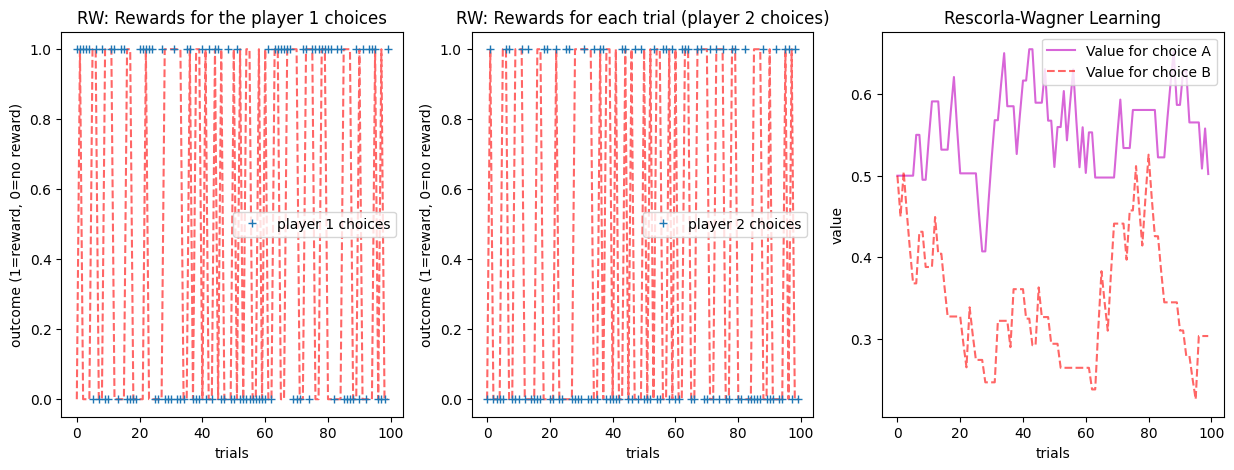

In [412]:
# plot the simulation
fig, axes = plt.subplots(ncols=3, figsize=(15, 5))

axes[0].plot(range(T), simulated_RW_r, 'r--', alpha=.6)
axes[0].plot(range(T), simulated_RW_c, '+', label='player 1 choices')

axes[0].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'RW: Rewards for the player 1 choices')
axes[0].legend()

axes[1].plot(range(T), simulated_RW_r, 'r--', alpha=.6)
axes[1].plot(range(T), player_2, '+', label='player 2 choices')

axes[1].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'RW: Rewards for each trial (player 2 choices)')
axes[1].legend()

# plot the simulation
axes[2].plot(range(T), simulated_RW_Q[0,:], 'm-', alpha=.6, label='Value for choice A')
axes[2].plot(range(T), simulated_RW_Q[1,:], 'r--', alpha=.6, label='Value for choice B')
axes[2].set(ylabel=r'value',
            xlabel=r'trials',
            title=fr'Rescorla-Wagner Learning')
axes[2].legend()

plt.show()

We generated data for player 1 with a simple Rescola-Wagner RL model. The plots show the actual value that player 1 used to make his decisions.

### B. QL-Boltzmann

Next, we simulate data for player 1 with a Q-Learning algorithm, learning rate alpha=.1, gamma=.1 and temperature beta=1.5.  
The QL-Boltzmann uses a softmax for action selection.

In [413]:
def simulate_QLearning_boltzmann(params, T, mu, player_2):

    alpha, gamma, beta = params

    c = np.zeros((T), dtype=int)
    r = np.zeros((T), dtype=int)

    Q_stored = np.zeros((T, 2), dtype=float)  # Q-stored matrix shape adjusted
    Q = np.zeros([2])  # Initialize Q-values for two actions

    for t in range(T):

        # Store values for Q_{t+1}
        Q_stored[t] = Q

        # Compute action probabilities using softmax
        exp_values = np.exp(Q / beta)
        probs = exp_values / np.sum(exp_values)

        # Choose action according to the Boltzmann policy
        c[t] = np.random.choice([0, 1], p=probs)

        # Generate reward based on coordination with player_2 choice
        r[t] = int(c[t] == player_2[t])

        # Update Q-values based on the observed reward
        action = c[t]
        reward = r[t]
        next_state = min(t + 1, T - 1)
        Q_next_state = Q_stored[next_state]
        
        td_target = reward + gamma * np.max(Q_next_state)
        td_error = td_target - Q[action]
        Q[action] = Q[action] + alpha * td_error

    return c, r, Q_stored


In [414]:
simulated_QL_boltzmann_c, simulated_QL_boltzmann_r, simulated_QL_boltzmann_Q = simulate_QLearning_boltzmann([.1, .1, 1.5], T=T, mu=mu, player_2=player_2)

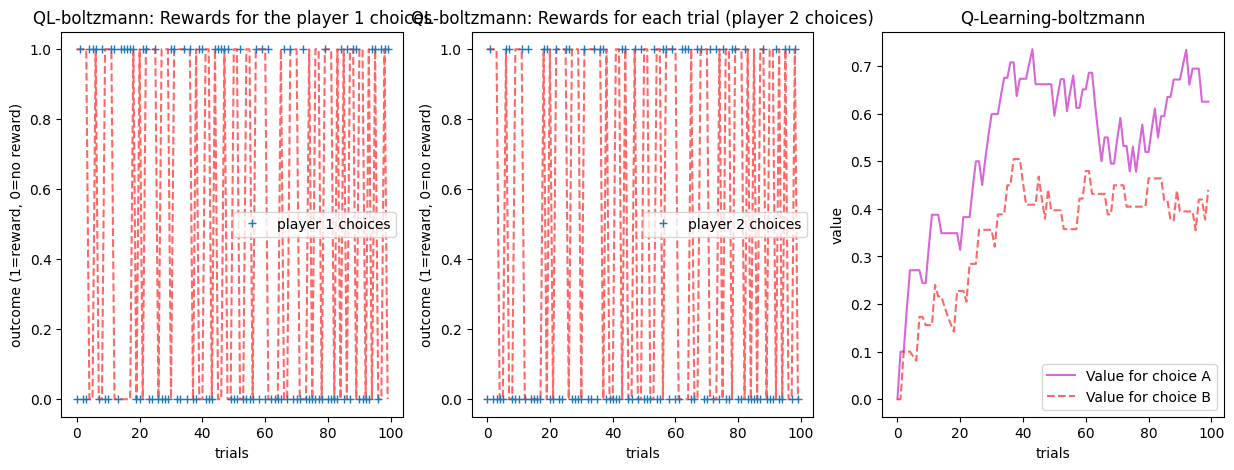

In [415]:
# plot the simulation
fig, axes = plt.subplots(ncols=3, figsize=(15, 5))

axes[0].plot(range(T), simulated_QL_boltzmann_r, 'r--', alpha=.6)
axes[0].plot(range(T), simulated_QL_boltzmann_c, '+', label='player 1 choices')

axes[0].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'QL-boltzmann: Rewards for the player 1 choices')
axes[0].legend()

axes[1].plot(range(T), simulated_QL_boltzmann_r, 'r--', alpha=.6)
axes[1].plot(range(T), player_2, '+', label='player 2 choices')

axes[1].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'QL-boltzmann: Rewards for each trial (player 2 choices)')
axes[1].legend()

# plot the simulation
axes[2].plot(range(T), simulated_QL_boltzmann_Q[:,0], 'm-', alpha=.6, label='Value for choice A')
axes[2].plot(range(T), simulated_QL_boltzmann_Q[:,1], 'r--', alpha=.6, label='Value for choice B')
axes[2].set(ylabel=r'value',
            xlabel=r'trials',
            title=fr'Q-Learning-boltzmann')
axes[2].legend()

plt.show()

We generated data for player 1 with a Q-Learning-softmax model. The plots show the actual value that player 1 used to make his decisions.

### C. QL-greedy

Greedy action selection

In [416]:
def simulate_QLearning_greedy(params, T, player_2):
    alpha, gamma = params

    c = np.zeros((T), dtype=int)
    r = np.zeros((T), dtype=int)

    Q_stored = np.zeros((T, 2), dtype=float)  # Q-stored matrix shape adjusted
    Q = np.zeros([2])  # Initialize Q-values for two actions

    for t in range(T):

        # Store values for Q_{t+1}
        Q_stored[t] = Q

        # Choose action according to the max argument
        if np.sum(Q) == 0:
            c[t] = np.random.choice([0, 1])  # Choose randomly if Q-values are all zeros
        else:
            c[t] = np.argmax(Q)

        # Generate reward based on coordination with player_2 choice
        r[t] = int(c[t] == player_2[t])

        # Update Q-values based on the observed reward
        action = c[t]
        reward = r[t]
        
        # Calculate the Q-value of the next state
        next_state = min(t + 1, T - 1)
        Q_next_state = Q_stored[next_state]

        # Calculate the temporal difference target
        td_target = reward + gamma * np.max(Q_next_state)

        # Calculate the temporal difference error
        td_error = td_target - Q[action]

        # Update Q-value of the chosen action
        Q[action] = Q[action] + alpha * td_error
        print(Q)

    return c, r, Q_stored


In [417]:
simulated_QL_greedy_c, simulated_QL_greedy_r, simulated_QL_greedy_Q = simulate_QLearning_greedy([.1, .1], T=T, player_2=player_2)

[0.1 0. ]
[0.09 0.  ]
[0.181 0.   ]
[0.2629 0.    ]
[0.33661 0.     ]
[0.402949 0.      ]
[0.3626541 0.       ]
[0.32638869 0.        ]
[0.39374982 0.        ]
[0.45437484 0.        ]
[0.50893736 0.        ]
[0.45804362 0.        ]
[0.51223926 0.        ]
[0.46101533 0.        ]
[0.5149138 0.       ]
[0.56342242 0.        ]
[0.60708018 0.        ]
[0.64637216 0.        ]
[0.58173494 0.        ]
[0.52356145 0.        ]
[0.5712053 0.       ]
[0.61408477 0.        ]
[0.5526763 0.       ]
[0.59740867 0.        ]
[0.6376678 0.       ]
[0.57390102 0.        ]
[0.51651092 0.        ]
[0.56485983 0.        ]
[0.60837384 0.        ]
[0.64753646 0.        ]
[0.68278281 0.        ]
[0.61450453 0.        ]
[0.65305408 0.        ]
[0.68774867 0.        ]
[0.6189738 0.       ]
[0.65707642 0.        ]
[0.59136878 0.        ]
[0.5322319 0.       ]
[0.57900871 0.        ]
[0.62110784 0.        ]
[0.65899706 0.        ]
[0.69309735 0.        ]
[0.72378762 0.        ]
[0.65140885 0.        ]
[0.58626797 

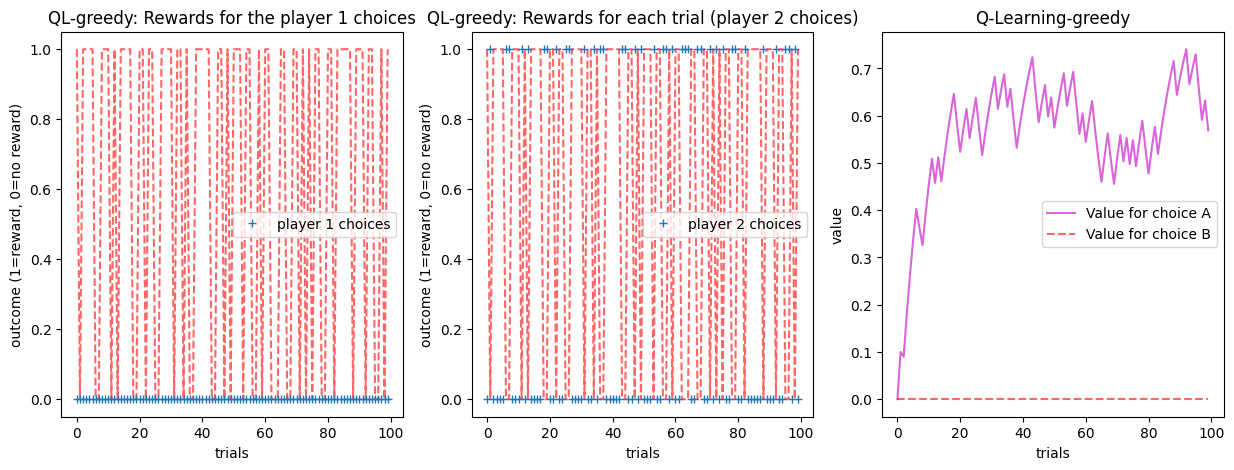

In [418]:
# plot the simulation
fig, axes = plt.subplots(ncols=3, figsize=(15, 5))

axes[0].plot(range(T), simulated_QL_greedy_r, 'r--', alpha=.6)
axes[0].plot(range(T), simulated_QL_greedy_c, '+', label='player 1 choices')

axes[0].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'QL-greedy: Rewards for the player 1 choices')
axes[0].legend()

axes[1].plot(range(T), simulated_QL_greedy_r, 'r--', alpha=.6)
axes[1].plot(range(T), player_2, '+', label='player 2 choices')

axes[1].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'QL-greedy: Rewards for each trial (player 2 choices)')
axes[1].legend()

# plot the simulation
axes[2].plot(range(T), simulated_QL_greedy_Q[:,0], 'm-', alpha=.6, label='Value for choice A')
axes[2].plot(range(T), simulated_QL_greedy_Q[:,1], 'r--', alpha=.6, label='Value for choice B')
axes[2].set(ylabel=r'value',
            xlabel=r'trials',
            title=fr'Q-Learning-greedy')
axes[2].legend()

plt.show()

The Q-Learning greedy uses only 1 single choice parameter.  
As we can see, with the greedy strategy, when one action is rewarding for the first time, it becomes always selected, resulting in no exploration.

### D. QL-e-greedy

Epsilon-greedy action selection.

In [419]:
def simulate_QLearning_egreedy(params, T, player_2):
    alpha, gamma, epsilon = params

    c = np.zeros((T), dtype=int)
    r = np.zeros((T), dtype=int)

    Q_stored = np.zeros((T, 2), dtype=float)  # Q-stored matrix shape adjusted
    Q = np.zeros([2])  # Initialize Q-values for two actions

    for t in range(T):

        # Store values for Q_{t+1}
        Q_stored[t] = Q

        # Choose action according to epsilon-greedy strategy
        if np.random.rand() < epsilon:
            c[t] = np.random.choice([0, 1])
        else:
            c[t] = np.argmax(Q)

        # Generate reward based on coordination with player_2 choice
        r[t] = int(c[t] == player_2[t])

        # Update Q-values based on the observed reward
        action = c[t]
        reward = r[t]
        
        next_state = min(t + 1, T - 1)
        Q_next_state = Q_stored[next_state]

        td_target = reward + gamma * np.max(Q_next_state)
        td_error = td_target - Q[action]
        Q[action] = Q[action] + alpha * td_error

    return c, r, Q_stored


In [420]:
simulated_QL_egreedy_c, simulated_QL_egreedy_r, simulated_QL_egreedy_Q = simulate_QLearning_egreedy([.1, .1, 0.1], T=T, player_2=player_2)

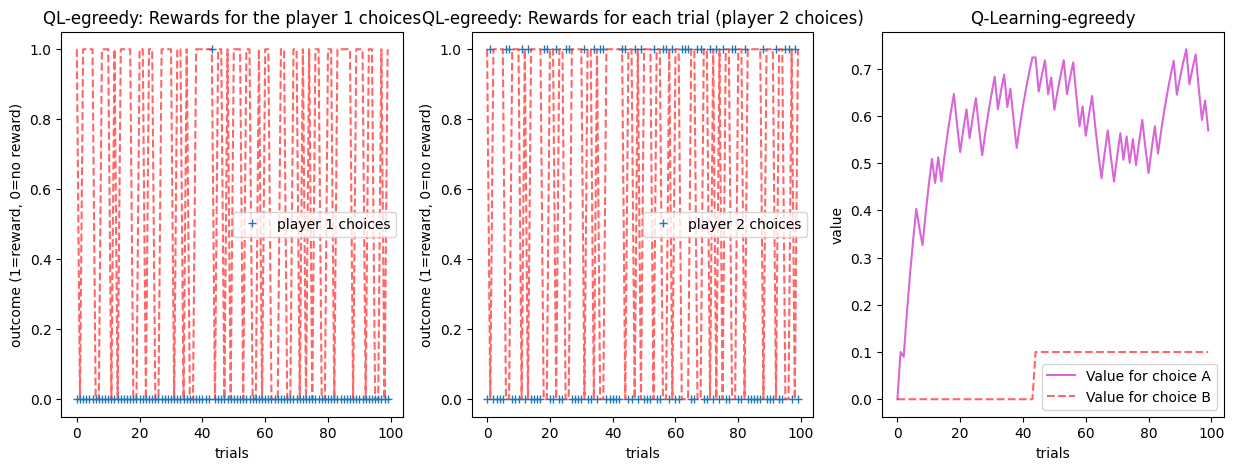

In [421]:
# plot the simulation
fig, axes = plt.subplots(ncols=3, figsize=(15, 5))

axes[0].plot(range(T), simulated_QL_egreedy_r, 'r--', alpha=.6)
axes[0].plot(range(T), simulated_QL_egreedy_c, '+', label='player 1 choices')

axes[0].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'QL-egreedy: Rewards for the player 1 choices')
axes[0].legend()

axes[1].plot(range(T), simulated_QL_egreedy_r, 'r--', alpha=.6)
axes[1].plot(range(T), player_2, '+', label='player 2 choices')

axes[1].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'QL-egreedy: Rewards for each trial (player 2 choices)')
axes[1].legend()

# plot the simulation
axes[2].plot(range(T), simulated_QL_egreedy_Q[:,0], 'm-', alpha=.6, label='Value for choice A')
axes[2].plot(range(T), simulated_QL_egreedy_Q[:,1], 'r--', alpha=.6, label='Value for choice B')
axes[2].set(ylabel=r'value',
            xlabel=r'trials',
            title=fr'Q-Learning-egreedy')
axes[2].legend()

plt.show()

The Q-Learning e-greedy uses 2 choice parameters.  
Given the epsilon parameter, there is a bit of exploration.

### E. QL-UCB

In [19]:
def simulate_QLearning_UCB(params, T, player_2):
    alpha, gamma, c_param = params

    c = np.zeros((T), dtype=int)
    r = np.zeros((T), dtype=int)

    Q_stored = np.zeros((T, 2), dtype=float)  # Q-stored matrix shape adjusted
    Q = np.zeros([2])  # Initialize Q-values for two actions
    N = np.zeros([2], dtype=int)  # Action count for UCB

    for t in range(T):

        # Store values for Q_{t+1}
        Q_stored[t] = Q

        # Compute UCB values for each action
        total_counts = np.sum(N) + 1  # Total counts +1 to avoid division by zero
        ucb_values = Q + c_param * np.sqrt(np.log(total_counts) / (N + 1))

        # Choose action with the highest UCB value
        c[t] = np.argmax(ucb_values)

        # Generate reward based on coordination with player_2 choice
        r[t] = int(c[t] == player_2[t])

        # Update Q-values based on the observed reward
        action = c[t]
        reward = r[t]
        N[action] += 1  # Update action count
        next_state = min(t + 1, T - 1)
        Q_next_state = Q_stored[next_state]
        
        td_target = reward + gamma * np.max(Q_next_state)
        td_error = td_target - Q[action]
        Q[action] = Q[action] + alpha * td_error

    return c, r, Q_stored

In [21]:
simulated_QL_UCB_c, simulated_QL_UCB_r, simulated_QL_UCB_Q = simulate_QLearning_UCB([.1, 1, 2], T=T, player_2=player_2)

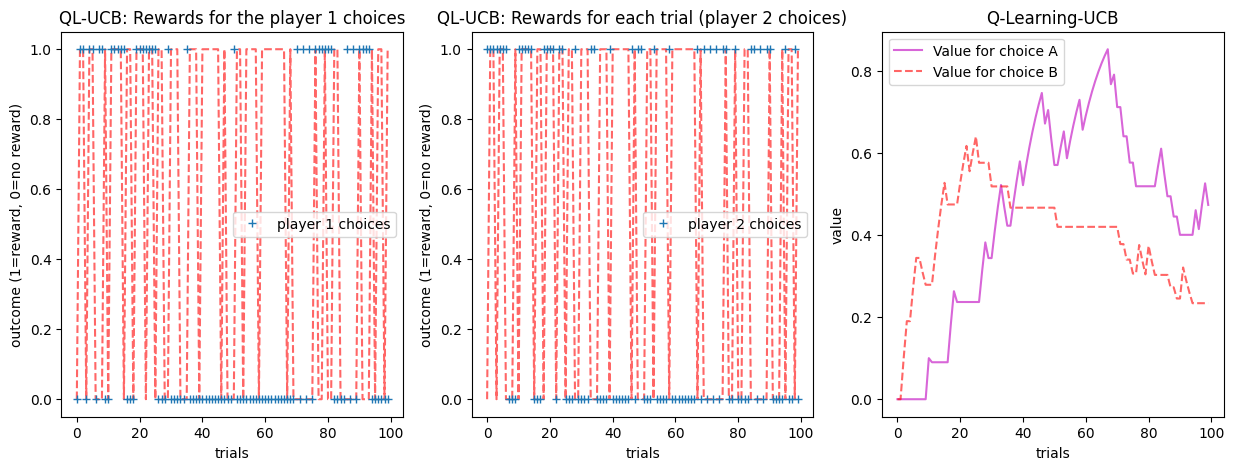

In [22]:
# plot the simulation
fig, axes = plt.subplots(ncols=3, figsize=(15, 5))

axes[0].plot(range(T), simulated_QL_UCB_r, 'r--', alpha=.6)
axes[0].plot(range(T), simulated_QL_UCB_c, '+', label='player 1 choices')

axes[0].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'QL-UCB: Rewards for the player 1 choices')
axes[0].legend()

axes[1].plot(range(T), simulated_QL_UCB_r, 'r--', alpha=.6)
axes[1].plot(range(T), player_2, '+', label='player 2 choices')

axes[1].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'QL-UCB: Rewards for each trial (player 2 choices)')
axes[1].legend()

# plot the simulation
axes[2].plot(range(T), simulated_QL_UCB_Q[:,0], 'm-', alpha=.6, label='Value for choice A')
axes[2].plot(range(T), simulated_QL_UCB_Q[:,1], 'r--', alpha=.6, label='Value for choice B')
axes[2].set(ylabel=r'value',
            xlabel=r'trials',
            title=fr'Q-Learning-UCB')
axes[2].legend()

plt.show()

### F. Double QL-greedy

In [422]:
import numpy as np

def simulate_QLearning_double_greedy(params, T, player_2):
    alpha, gamma = params

    c = np.zeros((T), dtype=int)
    r = np.zeros((T), dtype=int)

    Q1_stored = np.zeros((T, 2), dtype=float)  # Q1-stored matrix shape adjusted
    Q2_stored = np.zeros((T, 2), dtype=float)  # Q2-stored matrix shape adjusted
    Q1 = np.zeros([2])  # Initialize Q1-values for two actions
    Q2 = np.zeros([2])  # Initialize Q2-values for two actions

    for t in range(T):

        # Store values for Q1_{t+1} and Q2_{t+1}
        Q1_stored[t] = Q1
        Q2_stored[t] = Q2

        # Choose action according to argmax strategy based on combined Q-values
        Q_combined = Q1 + Q2
        max_Q_combined = np.max(Q_combined)
        c[t] = np.random.choice(np.where(Q_combined == max_Q_combined)[0])

        # Generate reward based on coordination with player_2 choice
        r[t] = int(c[t] == player_2[t])

        # Update Q1 or Q2 based on the observed reward
        action = c[t]
        reward = r[t]
        
        # Randomly choose which Q-value to update
        if np.random.rand() < 0.5:
            Q = Q1
            max_Q_other = np.max(Q2)
        else:
            Q = Q2
            max_Q_other = np.max(Q1)
            
        # Calculate the temporal difference target based on the selected Q-value and the maximum value from the other Q-function
        td_target = reward + gamma * max_Q_other

        # Calculate the temporal difference error
        td_error = td_target - Q[action]

        # Update the selected Q-value
        Q[action] = Q[action] + alpha * td_error

    return c, r, Q1_stored, Q2_stored


In [423]:
simulated_QL_double_greedy_c, simulated_QL_double_greedy_r, simulated_QL_double_greedy_Q1, simulated_QL_double_greedy_Q2 = simulate_QLearning_double_greedy([.1, .1], T=T, player_2=player_2)

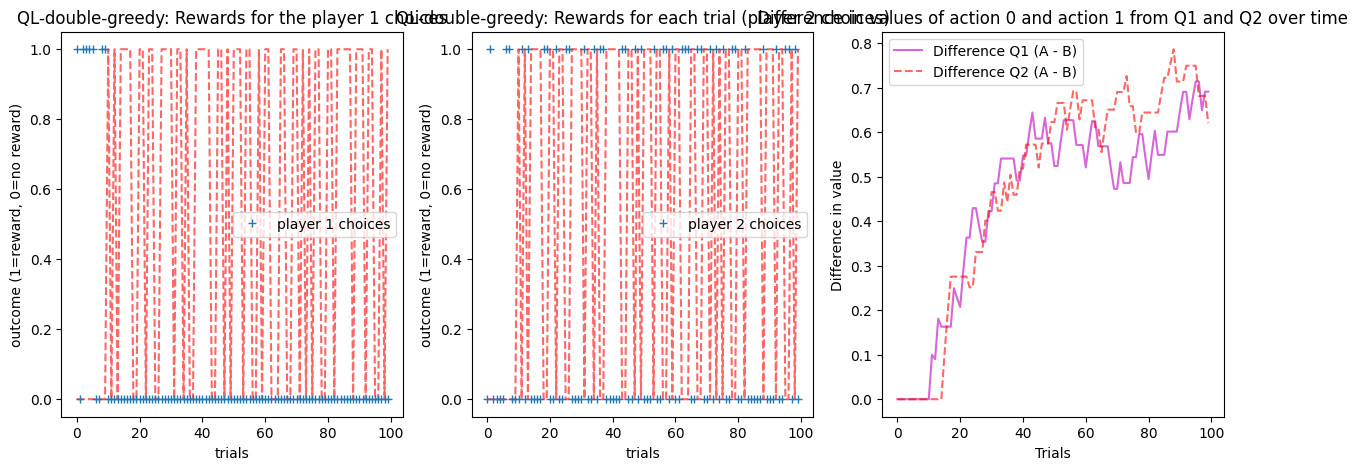

In [424]:
# plot the simulation
fig, axes = plt.subplots(ncols=3, figsize=(15, 5))

axes[0].plot(range(T), simulated_QL_double_greedy_r, 'r--', alpha=.6)
axes[0].plot(range(T), simulated_QL_double_greedy_c, '+', label='player 1 choices')

axes[0].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'QL-double-greedy: Rewards for the player 1 choices')
axes[0].legend()

axes[1].plot(range(T), simulated_QL_double_greedy_r, 'r--', alpha=.6)
axes[1].plot(range(T), player_2, '+', label='player 2 choices')

axes[1].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'QL-double-greedy: Rewards for each trial (player 2 choices)')
axes[1].legend()

# Calculate the differences between values of action 0 and action 1 from both Q1 and Q2 over time
difference_Q1 = simulated_QL_double_greedy_Q1[:, 0] - simulated_QL_double_greedy_Q1[:, 1]
difference_Q2 = simulated_QL_double_greedy_Q2[:, 0] - simulated_QL_double_greedy_Q2[:, 1]

# Plot the differences over time
axes[2].plot(range(T), difference_Q1, 'm-', alpha=0.6, label='Difference Q1 (A - B)')
axes[2].plot(range(T), difference_Q2, 'r--', alpha=0.6, label='Difference Q2 (A - B)')
axes[2].set(ylabel='Difference in value',
            xlabel='Trials',
            title='Difference in values of action 0 and action 1 from Q1 and Q2 over time')
axes[2].legend()


plt.show()

The update process involves choosing one of the Q-functions (Q1 or Q2) randomly and then updating the selected Q-function based on the observed reward and the maximum Q-value from the other Q-function. This way, each Q-function is updated independently, but both contribute to action selection. By alternating between Q1 and Q2 for action selection and updating, Double Q-learning aims to reduce the impact of overestimation bias and improve the learning process.

In both Q1 and Q2, A has always more value than B, explaining why action A (0) is always chosen.

### G. Double QL-e-greedy

In [425]:
def simulate_QLearning_double_egreedy(params, T, mu, player_2):
    alpha, gamma, epsilon = params

    c = np.zeros((T), dtype=int)
    r = np.zeros((T), dtype=int)

    Q1_stored = np.zeros((T, 2), dtype=float)  # Q1-stored matrix shape adjusted
    Q2_stored = np.zeros((T, 2), dtype=float)  # Q2-stored matrix shape adjusted
    Q1 = np.zeros([2])  # Initialize Q1-values for two actions
    Q2 = np.zeros([2])  # Initialize Q2-values for two actions

    for t in range(T):

        # Store values for Q1_{t+1} and Q2_{t+1}
        Q1_stored[t] = Q1
        Q2_stored[t] = Q2

        # Choose action according to epsilon-greedy strategy based on Q1 and Q2
        if np.random.rand() < epsilon:
            c[t] = np.random.choice([0, 1])
        else:
            max_Q = np.maximum(Q1, Q2)
            c[t] = np.argmax(max_Q)

        # Generate reward based on coordination with player_2 choice
        r[t] = int(c[t] == player_2[t])

        # Update Q1 or Q2 based on the observed reward
        action = c[t]
        reward = r[t]
        next_state = min(t + 1, T - 1)
        
        # Randomly choose which Q-value to update
        if np.random.rand() < 0.5:
            Q = Q1
        else:
            Q = Q2
            
        td_target = reward + gamma * np.max(Q1) + gamma * np.max(Q2) # Double Q-learning
        td_error = td_target - Q[action]
        Q[action] = Q[action] + alpha * td_error

    return c, r, Q1_stored, Q2_stored

In [426]:
simulated_QL_double_egreedy_c, simulated_QL_double_egreedy_r, simulated_QL_double_egreedy_Q1, simulated_QL_double_egreedy_Q2 = simulate_QLearning_double_egreedy([.1, .1, .2], T=T, mu=mu, player_2=player_2)

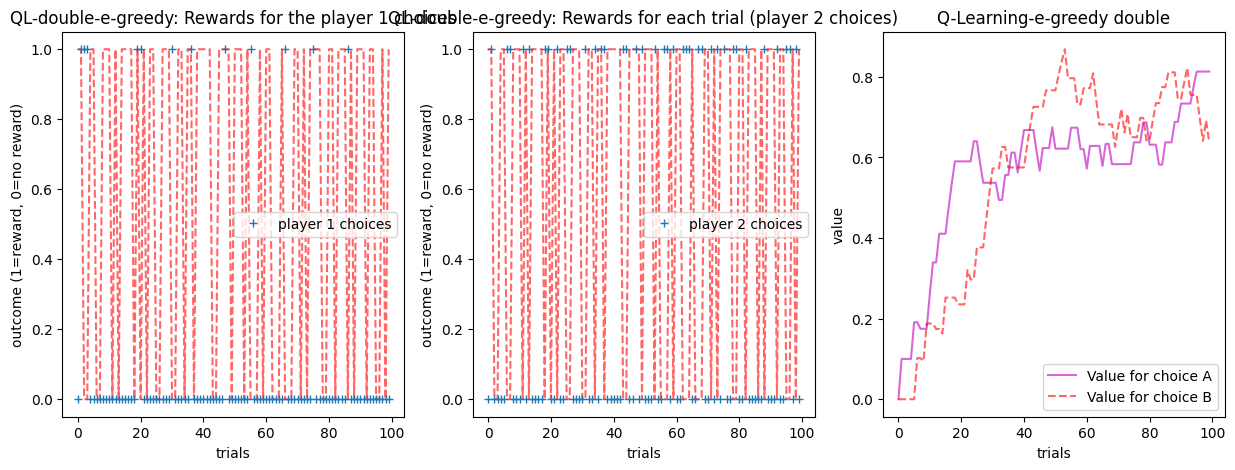

In [427]:
# plot the simulation
fig, axes = plt.subplots(ncols=3, figsize=(15, 5))

axes[0].plot(range(T), simulated_QL_double_egreedy_r, 'r--', alpha=.6)
axes[0].plot(range(T), simulated_QL_double_egreedy_c, '+', label='player 1 choices')

axes[0].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'QL-double-e-greedy: Rewards for the player 1 choices')
axes[0].legend()

axes[1].plot(range(T), simulated_QL_double_egreedy_r, 'r--', alpha=.6)
axes[1].plot(range(T), player_2, '+', label='player 2 choices')

axes[1].set(ylabel=r'outcome (1=reward, 0=no reward)',
            xlabel=r'trials',
            title=fr'QL-double-e-greedy: Rewards for each trial (player 2 choices)')
axes[1].legend()

# plot the simulation
axes[2].plot(range(T), simulated_QL_double_egreedy_Q1[:,0], 'm-', alpha=.6, label='Value for choice A')
axes[2].plot(range(T), simulated_QL_double_egreedy_Q2[:,0], 'r--', alpha=.6, label='Value for choice B')
axes[2].set(ylabel=r'value',
            xlabel=r'trials',
            title=fr'Q-Learning-e-greedy double')
axes[2].legend()

plt.show()

## 3. Fitting player 1 with RW

### A. Generate choices
We generate choices probabilities for player 1 with a simple Rescola-Wagner RL model.

In [428]:
def negll_RescorlaWagner(params, c, r):
    alpha, theta = params

    Q = [0.5, 0.5]
    T = len(c)
    choiceProb = np.zeros((T), dtype = float)

    for t in range(T):

        # compute choice probabilities for k=2
        p0 = np.exp(theta*Q[0]) / (np.exp(theta*Q[0]) + np.exp(theta*Q[1]))
        p = [p0, 1-p0]

        # compute choice probability for actual choice
        choiceProb[t] = p[c[t]]

        # We simulated choices, and their corresponding rewards, in the previous RescorlaWagner function with some alpha and theta parameters
        # Here we use different parameters to generate choice probabilities, so that we can compare the yhat data, generated from those new parameters, with the y data generated with the previous parameters

        # update values
        delta = r[t] - Q[c[t]]
        Q[c[t]] = Q[c[t]] + alpha * delta

    negLL = -np.sum(np.log(choiceProb))

    return negLL

### B. Fitting

We fit by using gradient ascent for finding the best parameters.  
We evaluate negative log-likelihood for this simulated dataset by finding the best parameters via a gradient descent minimization algorithm.

In [429]:
# gradient descent to minimize neg LL
res_nll = np.inf # set initial neg LL to be inf

# guess several different starting points for alpha
for alpha_guess in np.linspace(0.1,1,10):
    for theta_guess in np.linspace(0.1,25,10):

        # guesses for alpha, theta will change on each loop
        init_guess = (alpha_guess, theta_guess)

        # minimize neg LL
        result = minimize(negll_RescorlaWagner,
                          init_guess,
                          (simulated_RW_c, simulated_RW_r),
                          bounds=((0.1,1),(0.1,50)))

        # if current negLL is smaller than the last negLL,
        # then store current data
        if result.fun < res_nll:
            res_nll = result.fun
            param_fits = result.x

# also, compute BIC
# note: we don't need the -1 because
# we already have the negative log likelihood!
BIC = len(init_guess) * np.log(len(simulated_RW_c)) + 2*res_nll

print(fr'alpha_hat = {param_fits[0]:.2f}, theta_hat = {param_fits[1]:.2f}')
print(fr'BIC = {BIC:.2f}')

alpha_hat = 0.66, theta_hat = 0.88
BIC = 143.77


### C. Parameters recovery

The recipe for parameter recovery is quite simple
1. Simulate fake data with known parameter values
2. Fit the model to this fake data to try to 'recover' the parameters
3. Compare the recovered parameters to their true values

In [430]:
# simulate subjects' alpha and theta params
alpha_sim = stats.truncnorm.rvs((.1),
                                (1-.25),
                                loc=.25,
                                scale=1,
                                size=(50))
theta_sim = stats.truncnorm.rvs((0-.25),
                                (10-.25),
                                loc=1.25,
                                scale=1,
                                size=(50))

# initialize lists to store params and data
negll_sim = []
Q_fit = []
alpha_fit = []
theta_fit = []

# loop over subjects
for subj in range(50):
    np.random.seed(subj)

    alpha = alpha_sim[subj]
    theta = theta_sim[subj]

    # simulate subject data based on alpha, theta
    c_sim, r_sim, Q_sim = simulate_RescorlaWagner([alpha, theta], T, mu, player_2);

    # gradient descent to minimize neg LL
    res_nll = np.inf

    # guess several different starting points for alpha
    for alpha_guess in np.linspace(0.1,1,10):

        # guesses for alpha will change
        # guesses for theta will be constant
        init_guess = (alpha_guess, 1.5)

        # minimize neg LL
        result = minimize(negll_RescorlaWagner,
                          init_guess,
                          (c_sim, r_sim),
                          bounds=((0.1,1),(0.1,20)))

        # if current negLL is smaller than the last negLL,
        # then store current data
        if result.fun < res_nll:
            res_nll = result.fun
            param_fits = result.x
            Q_vals = Q_sim

    # append model fits to lists
    negll_sim.append(res_nll)
    Q_fit.append(Q_vals)
    alpha_fit.append(param_fits[0])
    theta_fit.append(param_fits[1])

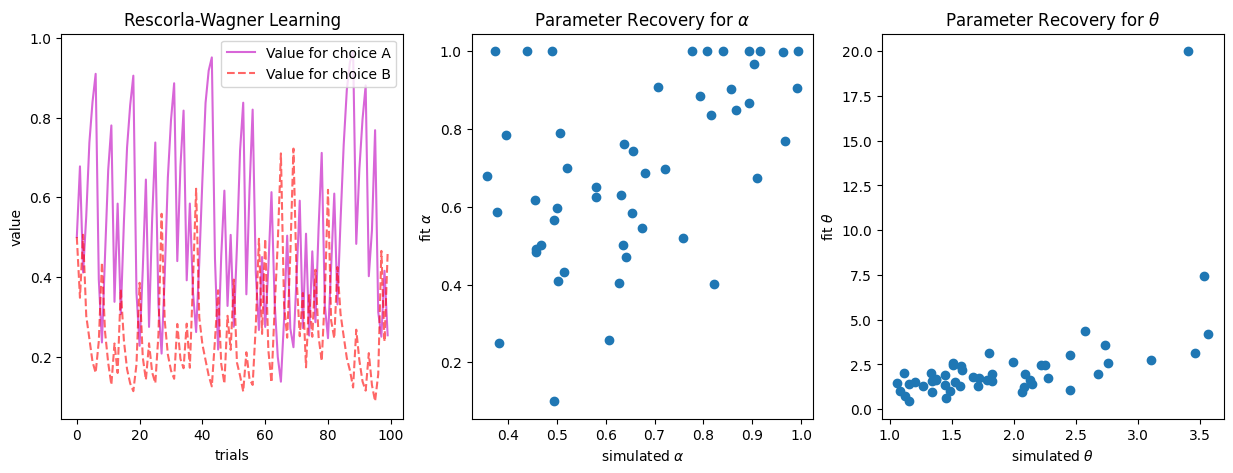

In [431]:
fig, axes = plt.subplots(ncols=3, figsize=(15, 5))

Q_means = np.mean(np.array(Q_fit), axis=0) # mean over subjects

axes[0].plot(range(T), Q_means[0,:], 'm-', alpha=.6, label='Value for choice A')
axes[0].plot(range(T), Q_means[1,:], 'r--', alpha=.6, label='Value for choice B')
axes[0].set(ylabel=r'value',
            xlabel=r'trials',
            title=fr'Rescorla-Wagner Learning')
axes[0].legend()

# parameter recovery for alpha
axes[1].plot(alpha_sim, alpha_fit, 'o')
axes[1].set(ylabel=r'fit $\alpha$',
            xlabel=r'simulated $\alpha$',
            title=fr'Parameter Recovery for $\alpha$')

axes[2].plot(theta_sim, theta_fit, 'o')
axes[2].set(ylabel=r'fit $\theta$',
            xlabel=r'simulated $\theta$',
            title=fr'Parameter Recovery for $\theta$')
plt.show()

## 4. Fitting player 1 with QL-Boltzmann

### A. Generate choices

We generate choices probabilities for player 1 with a simple Q-learning model.

Let's create a QLearning function with negLL incorporated:

In [432]:
def negll_QLearning_boltzmann(params, c, r):
    alpha, gamma, beta = params

    num_actions = 2  # Assuming binary actions
    Q = np.zeros((len(c) +1, num_actions))  # Initialize Q-table with zeros
    choiceProb = np.zeros(len(c))

    for t in range(len(c)):

        # compute choice probabilities for k=2
        exp_values = np.exp(Q[t] / beta)
        probs = exp_values / np.sum(exp_values)

        # compute choice probability for actual choice
        choiceProb[t] = probs[c[t]]

        # Update Q-value based on the observed reward
        reward = r[t]
        action = c[t]
        next_state = min(t + 1, len(c) - 1) # assuming state transitions follow time steps
        
        td_target = reward + gamma * np.max(Q[next_state])
        td_error = td_target - Q[t, action]
        Q[t, action] = Q[t, action] + alpha * td_error

    negLL = -np.sum(np.log(choiceProb))

    return negLL

### B. Fitting

We fit by using gradient ascent for finding the best parameters.  
We evaluate negative log-likelihood for this simulated dataset by finding the best parameters via a gradient descent minimization algorithm.

In [434]:
# gradient descent to minimize neg LL
res_nll = np.inf # set initial neg LL to be inf

# guess several different starting points for alpha
for alpha_guess in np.linspace(0.1,1,10):
    for gamma_guess in np.linspace(0.1,1,10):
        for beta_guess in np.linspace(0.1,25,10):

            # guesses for alpha, gamma, beta will change on each loop
            init_guess = (alpha_guess, gamma_guess, beta_guess)

            # minimize neg LL
            result = minimize(negll_QLearning_boltzmann,
                            init_guess,
                            (simulated_QL_boltzmann_c, simulated_QL_boltzmann_r),
                            bounds=((0.1,1),(0.1,1),(0.1,50)))

            # if current negLL is smaller than the last negLL,
            # then store current data
            if result.fun < res_nll:
                res_nll = result.fun
                param_fits = result.x

# also, compute BIC
# note: we don't need the -1 because
# we already have the negative log likelihood!
BIC = len(init_guess) * np.log(len(simulated_QL_boltzmann_c)) + 2*res_nll

print(fr'alpha_hat = {param_fits[0]:.2f}, gamma_hat = {param_fits[1]:.2f}, beta_hat = {param_fits[2]:.2f}')
print(fr'BIC = {BIC:.2f}')

alpha_hat = 0.10, gamma_hat = 0.10, beta_hat = 0.10
BIC = 152.44


The problem is, the model doesn't converge properly.

### C. Parameters recovery

The recipe for parameter recovery is quite simple
1. Simulate fake data with known parameter values
2. Fit the model to this fake data to try to 'recover' the parameters
3. Compare the recovered parameters to their true values

In [435]:
# simulate subjects' alpha and theta params
alpha_sim = stats.truncnorm.rvs((.1), 
                                (1-.25), 
                                loc=.25, 
                                scale=1, 
                                size=(50))
gamma_sim = stats.truncnorm.rvs((.1), 
                                (1-.25), 
                                loc=.25, 
                                scale=1, 
                                size=(50))
beta_sim = stats.truncnorm.rvs((0-.25), 
                                (10-.25), 
                                loc=1.25, 
                                scale=1, 
                                size=(50))


# initialize lists to store params and data
negll_sim = []
Q_fit = []
alpha_fit = []
gamma_fit = []
beta_fit = []

# loop over subjects
for subj in range(50):
    np.random.seed(subj)

    alpha = alpha_sim[subj]
    gamma = gamma_sim[subj]
    beta = beta_sim[subj]

    # simulate subject data based on alpha, theta
    c_sim, r_sim, Q_sim = simulate_QLearning_boltzmann([alpha, gamma, beta], T, mu, player_2);

    # gradient descent to minimize neg LL
    res_nll = np.inf

    # guess several different starting points for alpha
    for alpha_guess in np.linspace(0.1,1,10):

        # guesses for alpha will change
        # guesses for gamma and beta will be constant
        init_guess = (alpha_guess, 0.1, 1.5)

        # minimize neg LL
        result = minimize(negll_QLearning_boltzmann,
                          init_guess,
                          (c_sim, r_sim),
                          bounds=((0.1,1),(0.1,1),(0.1,20)))
                          

        # if current negLL is smaller than the last negLL,
        # then store current data
        if result.fun < res_nll:
            res_nll = result.fun
            param_fits = result.x
            Q_vals = Q_sim

    # append model fits to lists
    negll_sim.append(res_nll)
    Q_fit.append(Q_vals)
    alpha_fit.append(param_fits[0])
    gamma_fit.append(param_fits[1])
    beta_fit.append(param_fits[2])

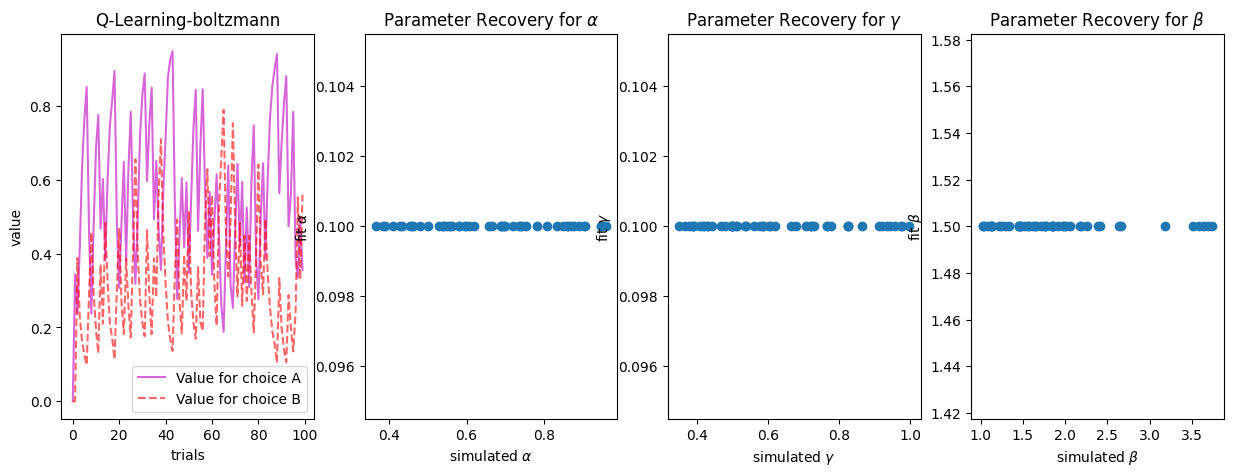

In [436]:
fig, axes = plt.subplots(ncols=4, figsize=(15, 5))

Q_means = np.mean(np.array(Q_fit), axis=0) # mean over subjects

axes[0].plot(range(T), Q_means[:,0], 'm-', alpha=.6, label='Value for choice A')
axes[0].plot(range(T), Q_means[:,1], 'r--', alpha=.6, label='Value for choice B')
axes[0].set(ylabel=r'value',
            xlabel=r'trials',
            title=fr'Q-Learning-boltzmann')
axes[0].legend()

# parameter recovery for alpha
axes[1].plot(alpha_sim, alpha_fit, 'o')
axes[1].set(ylabel=r'fit $\alpha$',
            xlabel=r'simulated $\alpha$',
            title=fr'Parameter Recovery for $\alpha$')

axes[2].plot(gamma_sim, gamma_fit, 'o')
axes[2].set(ylabel=r'fit $\gamma$',
            xlabel=r'simulated $\gamma$',
            title=fr'Parameter Recovery for $\gamma$')

axes[3].plot(beta_sim, beta_fit, 'o')
axes[3].set(ylabel=r'fit $\beta$',
            xlabel=r'simulated $\beta$',
            title=fr'Parameter Recovery for $\beta$')
plt.show()

# Playground for algorithms: 10-arm testbed

### We test the Q-Learning UCB vs Q-Learning optimistic egreedy algorithms

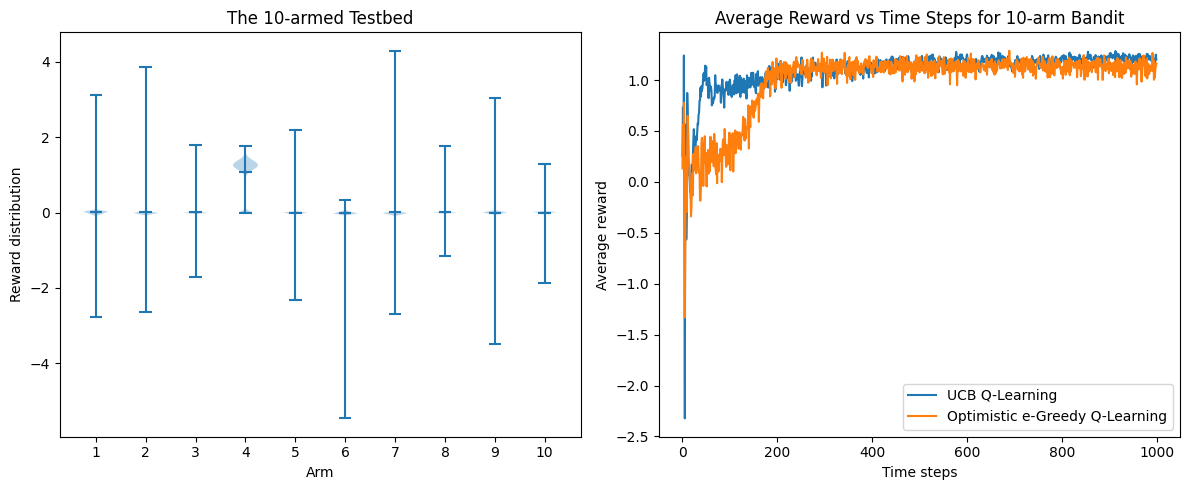

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def generate_bandit_params(num_arms, mean_mean=0, mean_sd=1, sd_mean=1, sd_sd=0.5):
    """Generates random means and standard deviations for each of the arms."""
    means = np.random.normal(mean_mean, mean_sd, num_arms)
    sds = np.random.normal(sd_mean, sd_sd, num_arms)
    sds = np.clip(sds, 0.1, None)  # Ensure standard deviations are positive and non-zero
    return means, sds

def simulate_QLearning_UCB(params, T, means, sds):
    alpha, gamma, c_param = params

    c = np.zeros(T, dtype=int)
    r = np.zeros(T, dtype=float)

    Q_stored = np.zeros((T, len(means)), dtype=float)  # Q-stored matrix for multiple arms
    Q = np.zeros(len(means))  # Initialize Q-values for multiple actions
    N = np.zeros(len(means), dtype=int)  # Action count for UCB

    for t in range(T):

        # Store values for Q_{t+1}
        Q_stored[t] = Q

        # Compute UCB values for each action
        total_counts = np.sum(N) + 1  # Total counts +1 to avoid division by zero
        ucb_values = Q + c_param * np.sqrt(np.log(total_counts) / (N + 1))

        # Choose action with the highest UCB value
        c[t] = np.argmax(ucb_values)

        # Generate reward based on the chosen action
        chosen_arm = c[t]
        r[t] = np.random.normal(means[chosen_arm], sds[chosen_arm])

        # Update Q-values based on the observed reward
        action = c[t]
        reward = r[t]
        N[action] += 1  # Update action count
        next_state = min(t + 1, T - 1)
        Q_next_state = Q_stored[next_state]
        
        td_target = reward + gamma * np.max(Q_next_state)
        td_error = td_target - Q[action]
        Q[action] = Q[action] + alpha * td_error

    return c, r, Q_stored

def simulate_QLearning_optimistic_eGreedy(params, T, means, sds, epsilon=0.1, initial_value=5.0):
    alpha, gamma = params

    c = np.zeros(T, dtype=int)
    r = np.zeros(T, dtype=float)

    Q_stored = np.zeros((T, len(means)), dtype=float)  # Q-stored matrix for multiple arms
    Q = np.ones(len(means)) * initial_value  # Initialize Q-values for multiple actions with optimistic initial value

    for t in range(T):

        # Store values for Q_{t+1}
        Q_stored[t] = Q

        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = np.random.choice(len(means))
        else:
            action = np.argmax(Q)

        c[t] = action

        # Generate reward based on the chosen action
        chosen_arm = c[t]
        r[t] = np.random.normal(means[chosen_arm], sds[chosen_arm])

        # Update Q-values based on the observed reward
        reward = r[t]
        next_state = min(t + 1, T - 1)
        Q_next_state = Q_stored[next_state]

        td_target = reward + gamma * np.max(Q_next_state)
        td_error = td_target - Q[action]
        Q[action] = Q[action] + alpha * td_error

    return c, r, Q_stored

def test_10_arm_bandit():
    num_arms = 10
    T = 1000  # Number of time steps
    num_runs = 100  # Number of simulation runs

    params_ucb = (0.1, 0.99, 2)  # alpha, gamma, c_param for UCB
    params_egreedy = (0.1, 0.99)  # alpha, gamma for e-greedy

    # Generate bandit parameters once
    means, sds = generate_bandit_params(num_arms)

    avg_rewards_ucb = np.zeros(T)
    avg_rewards_egreedy = np.zeros(T)
    all_means = np.zeros((num_runs, num_arms))
    all_sds = np.zeros((num_runs, num_arms))

    # Collect all rewards for violin plot
    all_rewards = np.zeros((num_runs, num_arms, T))

    for run in range(num_runs):
        all_means[run] = means
        all_sds[run] = sds

        # Simulate UCB
        choices_ucb, rewards_ucb, _ = simulate_QLearning_UCB(params_ucb, T, means, sds)
        avg_rewards_ucb += rewards_ucb

        # Simulate e-greedy with optimistic initial values
        choices_egreedy, rewards_egreedy, _ = simulate_QLearning_optimistic_eGreedy(params_egreedy, T, means, sds)
        avg_rewards_egreedy += rewards_egreedy

        for arm in range(num_arms):
            arm_rewards = rewards_ucb[choices_ucb == arm]
            all_rewards[run, arm, :len(arm_rewards)] = arm_rewards

    avg_rewards_ucb /= num_runs
    avg_rewards_egreedy /= num_runs

    # Plotting the true mean values and standard deviations of the 10 arms
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.violinplot([all_rewards[:, arm, :].flatten() for arm in range(num_arms)], showmeans=True)
    plt.xlabel('Arm')
    plt.ylabel('Reward distribution')
    plt.title('The 10-armed Testbed')
    plt.xticks(range(1, num_arms + 1))

    # Plotting average rewards over time
    plt.subplot(1, 2, 2)
    plt.plot(avg_rewards_ucb, label='UCB Q-Learning')
    plt.plot(avg_rewards_egreedy, label='Optimistic e-Greedy Q-Learning')
    plt.xlabel('Time steps')
    plt.ylabel('Average reward')
    plt.title('Average Reward vs Time Steps for 10-arm Bandit')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run the test
test_10_arm_bandit()
